**Import dependencies**

In [1]:
from fastai.vision.all import *

In [2]:
import inspect
import pandas as pd
pd.set_option('max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

def inspect_default_args(target, annotations: bool=False):
    # Get the argument names
    args = inspect.getfullargspec(target).args
    # Get the default values
    defaults = inspect.getfullargspec(target).defaults

    index = ["Default Value"]

    # Pad defaults
    defaults = [None]*(len(args)-len(defaults)) + list(defaults)
    if annotations:
        index.append("Annotation")
        annotations = inspect.getfullargspec(target).annotations.values()
        # Pad annotations
        annotations = [None]*(len(args)-len(annotations)) + list(annotations)
        default_args = {arg:[df, annot] for arg,df,annot in zip(args, defaults, annotations)}
    else:
        default_args = {arg:[default] for arg,default in zip(args, defaults)}
        
    return pd.DataFrame(default_args, index=index).T

**Define path to dataset**

In [3]:
path = untar_data(URLs.PETS)

In [4]:
path.ls()

(#3) [Path('/home/innom-dt/.fastai/data/oxford-iiit-pet/models'),Path('/home/innom-dt/.fastai/data/oxford-iiit-pet/annotations'),Path('/home/innom-dt/.fastai/data/oxford-iiit-pet/images')]

In [5]:
files = get_image_files(path/"images")
len(files)

7390

**Define Lables**

In [6]:
files[0], files[6]

(Path('/home/innom-dt/.fastai/data/oxford-iiit-pet/images/wheaten_terrier_19.jpg'),
 Path('/home/innom-dt/.fastai/data/oxford-iiit-pet/images/Sphynx_89.jpg'))

In [7]:
files[0].name

'wheaten_terrier_19.jpg'

In [8]:
# Pattern to extract the pet breed from the file name
pat = r'^(.*)_\d+.jpg'

**Define Getters**

In [9]:
inspect_default_args(get_image_files)

,Default Value
path,None
recurse,True
folders,None


In [10]:
get_items = get_image_files
get_y = using_attr(RegexLabeller(pat), 'name')

**Define Transforms**

In [11]:
item_tfms = [Resize(224)]
batch_tfms = aug_transforms(size=224)

**Define custom DataBlock**

In [12]:
pets = DataBlock(blocks=(ImageBlock, CategoryBlock),
                 get_items=get_items,
                 splitter=RandomSplitter(),
                 get_y=get_y,
                 item_tfms=item_tfms,
                 batch_tfms=batch_tfms)

**Define batch size**

In [13]:
bs = 128

**Define DataLoaders object**

In [14]:
dls = pets.dataloaders(path/'images', bs=bs)

**Verify DataLoaders object**

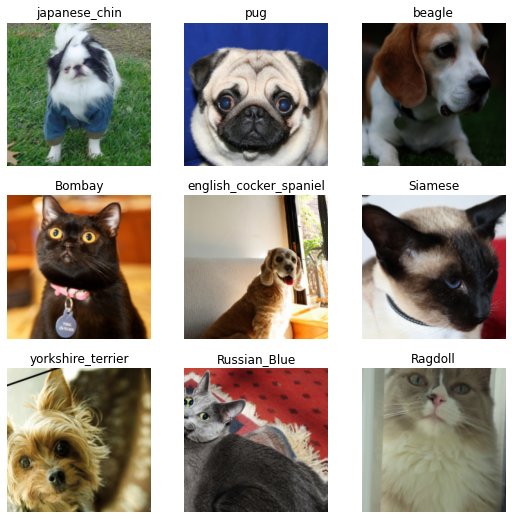

In [15]:
dls.show_batch()

**Inspect Learner parameters**

In [16]:
inspect_default_args(vision_learner)

,Default Value
dls,None
arch,None
normalize,True
n_out,None
pretrained,True
loss_func,None
opt_func,<function Adam at 0x7f160c6ae3b0>
lr,0.001
splitter,None
cbs,None


**Define model**

In [17]:
model = resnet34

**Define [metrics](https://docs.fast.ai/metrics.html)**

In [18]:
metrics = [error_rate, accuracy]

**Define Learner object**

In [19]:
learn = vision_learner(dls, model, metrics=metrics).to_fp16()

**Find learning rate**

In [20]:
inspect_default_args(learn.lr_find)

,Default Value
self,None
start_lr,0.0
end_lr,10
num_it,100
stop_div,True
show_plot,True
suggest_funcs,<function valley at 0x7f160c3fd510>


**Define [suggestion methods](https://docs.fast.ai/callback.schedule.html#Suggestion-Methods)**

In [21]:
suggest_funcs = [valley, minimum, steep]

SuggestedLRs(valley=0.0006918309954926372, minimum=0.014454397559165954, steep=0.0020892962347716093)

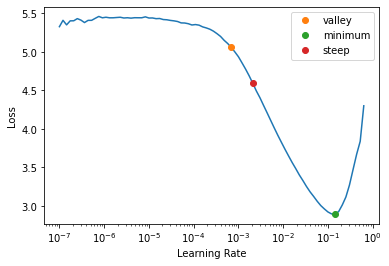

In [22]:
learn.lr_find(suggest_funcs=suggest_funcs)

**Define learning rate**

In [23]:
lr = 2e-3
lr

0.002

**Define number of epochs**

In [24]:
epochs = 2

**Fine tune model**

In [25]:
inspect_default_args(learn.fine_tune)

,Default Value
self,None
epochs,None
base_lr,0.002
freeze_epochs,1
lr_mult,100
pct_start,0.3
div,5.0
lr_max,None
div_final,100000.0
wd,None


In [26]:
learn.fine_tune(epochs, base_lr=lr)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,2.207645,0.363181,0.117050,0.882950,00:09


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.489726,0.290064,0.092016,0.907984,00:11
1,0.359136,0.262229,0.076455,0.923545,00:10


**Select a test image**

In [27]:
import PIL

In [28]:
test_file = files[0]
test_file.name

'wheaten_terrier_19.jpg'

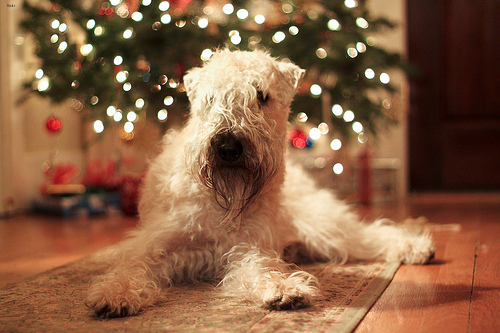

In [29]:
test_img = PIL.Image.open(test_file)
test_img

**Make a prediction on a single image using a file path**

In [30]:
learn.predict(test_file)

('wheaten_terrier',
 TensorBase(35),
 TensorBase([1.8787e-08, 3.5542e-09, 1.7058e-07, 1.3039e-08, 1.9308e-08, 5.5993e-08,
         3.4248e-09, 3.6266e-08, 2.6054e-09, 1.0590e-08, 1.2824e-08, 2.9759e-08,
         7.5882e-08, 1.7384e-08, 1.3490e-09, 3.0047e-09, 3.6456e-09, 1.5772e-09,
         3.4024e-07, 3.9928e-08, 4.1702e-08, 4.2969e-07, 2.4269e-07, 8.0018e-09,
         5.1211e-09, 5.2135e-07, 8.9353e-09, 1.4672e-09, 1.7350e-08, 1.3481e-07,
         3.4328e-08, 4.7717e-08, 4.7391e-05, 3.2764e-08, 3.2362e-09, 9.9995e-01,
         9.4653e-09]))

**Make a prediction on a single image using a [fastai.vision.core.PILImage](https://docs.fast.ai/vision.core.html#PILImage)**

In [31]:
learn.predict(PILImage(test_img))

('wheaten_terrier',
 TensorBase(35),
 TensorBase([1.8787e-08, 3.5542e-09, 1.7058e-07, 1.3039e-08, 1.9308e-08, 5.5993e-08,
         3.4248e-09, 3.6266e-08, 2.6054e-09, 1.0590e-08, 1.2824e-08, 2.9759e-08,
         7.5882e-08, 1.7384e-08, 1.3490e-09, 3.0047e-09, 3.6456e-09, 1.5772e-09,
         3.4024e-07, 3.9928e-08, 4.1702e-08, 4.2969e-07, 2.4269e-07, 8.0018e-09,
         5.1211e-09, 5.2135e-07, 8.9353e-09, 1.4672e-09, 1.7350e-08, 1.3481e-07,
         3.4328e-08, 4.7717e-08, 4.7391e-05, 3.2764e-08, 3.2362e-09, 9.9995e-01,
         9.4653e-09]))

**Make a prediction on a single image using a [fastai.torch_core.tensor](https://docs.fast.ai/torch_core.html#tensor)**

In [32]:
learn.predict(tensor(test_img))

('wheaten_terrier',
 TensorBase(35),
 TensorBase([1.8787e-08, 3.5542e-09, 1.7058e-07, 1.3039e-08, 1.9308e-08, 5.5993e-08,
         3.4248e-09, 3.6266e-08, 2.6054e-09, 1.0590e-08, 1.2824e-08, 2.9759e-08,
         7.5882e-08, 1.7384e-08, 1.3490e-09, 3.0047e-09, 3.6456e-09, 1.5772e-09,
         3.4024e-07, 3.9928e-08, 4.1702e-08, 4.2969e-07, 2.4269e-07, 8.0018e-09,
         5.1211e-09, 5.2135e-07, 8.9353e-09, 1.4672e-09, 1.7350e-08, 1.3481e-07,
         3.4328e-08, 4.7717e-08, 4.7391e-05, 3.2764e-08, 3.2362e-09, 9.9995e-01,
         9.4653e-09]))

**Make predictions for a group of images**

In [33]:
inspect_default_args(learn.show_results)

,Default Value
self,None
ds_idx,1
dl,None
max_n,9
shuffle,True


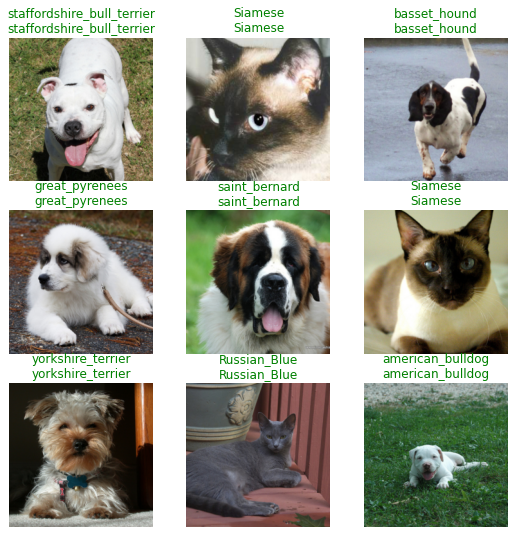

In [34]:
learn.show_results()

**Define an Interpretation object**

In [35]:
inspect_default_args(Interpretation.from_learner)

,Default Value
cls,None
learn,None
ds_idx,1
dl,None
act,None


In [36]:
interp = Interpretation.from_learner(learn)

**Plot top losses**

In [37]:
inspect_default_args(interp.plot_top_losses)

,Default Value
self,None
k,None
largest,True


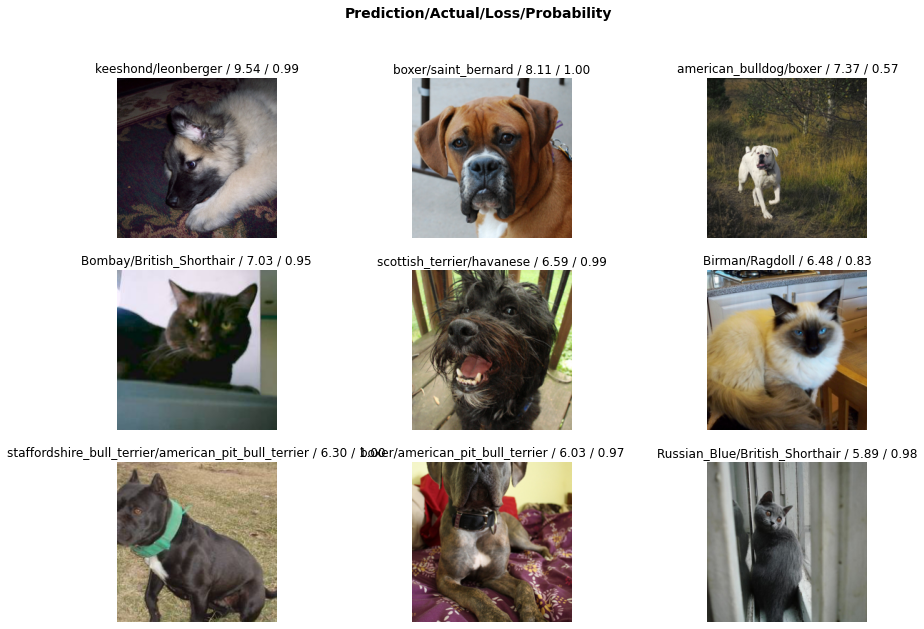

In [38]:
interp.plot_top_losses(k=9, figsize=(15,10))

In [39]:
learn.dls.after_item

Pipeline: Resize -- {'size': (224, 224), 'method': 'crop', 'pad_mode': 'reflection', 'resamples': (<Resampling.BILINEAR: 2>, 0), 'p': 1.0} -> ToTensor

In [40]:
learn.dls.after_batch

Pipeline: IntToFloatTensor -- {'div': 255.0, 'div_mask': 1} -> Flip -- {'size': 224, 'mode': 'bilinear', 'pad_mode': 'reflection', 'mode_mask': 'nearest', 'align_corners': True, 'p': 0.5} -> Brightness -- {'max_lighting': 0.2, 'p': 1.0, 'draw': None, 'batch': False} -> Normalize -- {'mean': tensor([[[[0.4850]],

         [[0.4560]],

         [[0.4060]]]], device='cuda:0'), 'std': tensor([[[[0.2290]],

         [[0.2240]],

         [[0.2250]]]], device='cuda:0'), 'axes': (0, 2, 3)}

In [61]:
learn.dls.vocab

['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

**Reset test image**

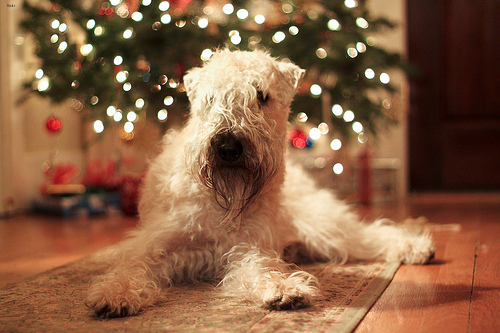

In [41]:
test_img = PIL.Image.open(test_file)
test_img

In [42]:
test_img.size

(500, 333)

In [43]:
min(test_img.size)

333

In [44]:
min_dim = test_img.size.index(min(test_img.size))
max_dim = 1 - min_dim

In [45]:
target_dim = 224

**Set input dims**

In [46]:
inp_dims = [0,0]
inp_dims[min_dim] = target_dim
inp_dims[max_dim] = int(test_img.size[max_dim] / (test_img.size[min_dim]/target_dim))
inp_dims

[336, 224]

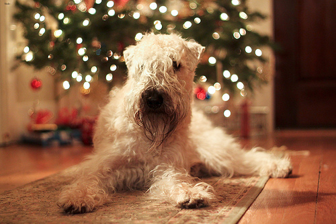

In [47]:
resized_img = test_img.resize(inp_dims)
resized_img

**Convert image to tensor**

In [48]:
img_tensor = tensor(resized_img).permute(2, 0, 1)
img_tensor.shape, img_tensor

(torch.Size([3, 224, 336]),
 tensor([[[168, 176, 177,  ...,  50,  50,  49],
          [166, 176, 179,  ...,  49,  47,  46],
          [166, 175, 182,  ...,  45,  43,  43],
          ...,
          [118, 120, 110,  ..., 147, 150, 147],
          [103, 105, 104,  ..., 144, 148, 149],
          [ 94, 106, 113,  ..., 141, 146, 149]],
 
         [[125, 137, 136,  ...,  22,  23,  24],
          [126, 135, 134,  ...,  20,  21,  22],
          [130, 134, 135,  ...,  23,  23,  22],
          ...,
          [ 73,  68,  66,  ...,  63,  65,  61],
          [ 64,  56,  55,  ...,  63,  64,  65],
          [ 52,  53,  56,  ...,  57,  60,  64]],
 
         [[ 83,  85,  83,  ...,  15,  14,  14],
          [ 77,  84,  85,  ...,  16,  17,  17],
          [ 79,  83,  86,  ...,  16,  15,  17],
          ...,
          [ 44,  43,  39,  ...,  41,  42,  39],
          [ 40,  35,  34,  ...,  40,  41,  40],
          [ 31,  35,  38,  ...,  36,  40,  41]]], dtype=torch.uint8))

**Scale tensor values**

In [49]:
scaled_tensor = img_tensor.float().div_(255)

**Prepare imagenet mean values**

In [50]:
mean_tensor = tensor(imagenet_stats[0]).view(1,1,-1).permute(2, 0, 1)
mean_tensor.shape, mean_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.4850]],
 
         [[0.4560]],
 
         [[0.4060]]]))

**Prepare imagenet std values**

In [51]:
std_tensor = tensor(imagenet_stats[1]).view(1,1,-1).permute(2, 0, 1)
std_tensor.shape, std_tensor

(torch.Size([3, 1, 1]),
 tensor([[[0.2290]],
 
         [[0.2240]],
 
         [[0.2250]]]))

**Normalize and batch image tensor**

In [52]:
normalized_tensor = (scaled_tensor - mean_tensor) / std_tensor
batched_tensor = normalized_tensor.unsqueeze(dim=0)
batched_tensor.shape, batched_tensor

(torch.Size([1, 3, 224, 336]),
 tensor([[[[ 0.7591,  0.8961,  0.9132,  ..., -1.2617, -1.2617, -1.2788],
           [ 0.7248,  0.8961,  0.9474,  ..., -1.2788, -1.3130, -1.3302],
           [ 0.7248,  0.8789,  0.9988,  ..., -1.3473, -1.3815, -1.3815],
           ...,
           [-0.0972, -0.0629, -0.2342,  ...,  0.3994,  0.4508,  0.3994],
           [-0.3541, -0.3198, -0.3369,  ...,  0.3481,  0.4166,  0.4337],
           [-0.5082, -0.3027, -0.1828,  ...,  0.2967,  0.3823,  0.4337]],
 
          [[ 0.1527,  0.3627,  0.3452,  ..., -1.6506, -1.6331, -1.6155],
           [ 0.1702,  0.3277,  0.3102,  ..., -1.6856, -1.6681, -1.6506],
           [ 0.2402,  0.3102,  0.3277,  ..., -1.6331, -1.6331, -1.6506],
           ...,
           [-0.7577, -0.8452, -0.8803,  ..., -0.9328, -0.8978, -0.9678],
           [-0.9153, -1.0553, -1.0728,  ..., -0.9328, -0.9153, -0.8978],
           [-1.1253, -1.1078, -1.0553,  ..., -1.0378, -0.9853, -0.9153]],
 
          [[-0.3578, -0.3230, -0.3578,  ..., -1.5430, -

**Pass tensor to model**

In [53]:
with torch.no_grad():
    preds = learn.model(batched_tensor.cuda())
preds

TensorBase([[-1.5232, -2.8691,  0.9211, -1.5295, -0.4497,  0.5103, -2.1177, -0.8428,
         -1.4649, -1.6088, -0.4369, -0.6584,  0.7206, -1.2631, -3.2449, -2.1864,
         -2.1053, -2.8997,  2.6146, -0.1508, -0.0944,  3.2164,  1.6209, -1.0330,
         -1.8533,  1.2939, -1.6670, -2.8074, -0.7549,  0.5151, -0.2854,  0.7582,
          6.0591, -0.9744, -2.5865, 14.6656, -1.6323]], device='cuda:0')

In [54]:
torch.nn.functional.softmax(preds, dim=1)

TensorBase([[9.3149e-08, 2.4248e-08, 1.0733e-06, 9.2563e-08, 2.7253e-07, 7.1176e-07,
         5.1403e-08, 1.8395e-07, 9.8746e-08, 8.5506e-08, 2.7603e-07, 2.2119e-07,
         8.7838e-07, 1.2082e-07, 1.6653e-08, 4.7992e-08, 5.2048e-08, 2.3517e-08,
         5.8375e-06, 3.6747e-07, 3.8877e-07, 1.0656e-05, 2.1611e-06, 1.5208e-07,
         6.6966e-08, 1.5582e-06, 8.0677e-08, 2.5792e-08, 2.0085e-07, 7.1517e-07,
         3.2120e-07, 9.1201e-07, 1.8288e-04, 1.6126e-07, 3.2166e-08, 9.9979e-01,
         8.3525e-08]], device='cuda:0')

**Process model output**

In [55]:
preds.argmax()

TensorBase(35, device='cuda:0')

In [56]:
torch.nn.functional.softmax(preds, dim=1)[0][preds.argmax()]

TensorBase(0.9998, device='cuda:0')

In [57]:
learn.dls.vocab[preds.argmax()]

'wheaten_terrier'

In [58]:
learn.dls.vocab[torch.nn.functional.softmax(preds, dim=1).argmax()]

'wheaten_terrier'

**Define ONNX file name**

In [59]:
onnx_file_name = f"{path.name}-{learn.arch.__name__}.onnx"
onnx_file_name

'oxford-iiit-pet-resnet34.onnx'

**Export trained model to ONNX**

In [60]:
torch.onnx.export(learn.model.cpu(),
                  batched_tensor,
                  onnx_file_name,
                  export_params=True,
                  opset_version=9,
                  do_constant_folding=True
                 )